# NB-based Normative Model CV Performance Comparison

| Model | 대상 유전자 | 방법 |
|---|---|---|
| **NBI GAMLSS** (`cv_gamlss_nb`) | det_rate ≥ 10% | NB count z-score (RQR) |
| **ZINBI GAMLSS** (`cv_gamlss_zinb`) | det_rate ≥ 10% | Full ZINBI RQR |
| **Logistic** (`cv_logistic`) | 1% ≤ det_rate < 10% | Bernoulli RQR |

평가 지표: **Anderson-Darling subsampled statistic** (n=200, B=100 중앙값), z-score mean/std/skew/kurt, fold 성공률

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CV_DIR = Path('CV_Results')

# ── Load available results ─────────────────────────────────────────
def load_if_exists(path):
    return pd.read_csv(path) if path.exists() else None

nb   = load_if_exists(CV_DIR / 'cv_gamlss_stats.csv')
zinb = load_if_exists(CV_DIR / 'cv_zinb_stats.csv')
logr = load_if_exists(CV_DIR / 'cv_logistic_stats.csv')

for name, df in [('NBI', nb), ('ZINBI', zinb), ('Logistic', logr)]:
    if df is not None:
        print(f'{name:10s}: {len(df):6,} genes loaded')
    else:
        print(f'{name:10s}: not found')

NBI       : 15,185 genes loaded
ZINBI     : 10,718 genes loaded
Logistic  :  2,762 genes loaded


## 1. 전체 요약 테이블

In [2]:
# Unified column mapping per model
def extract_metrics(df, label, ad_col, ad_pass_col, mz_col, sz_col, sk_col, ku_col, success_col, flag_col=None):
    if df is None:
        return None
    d = pd.DataFrame({
        'model':        label,
        'gene':         df['gene'],
        'det_rate':     df['det_rate_hc'],
        'ad_sub':       df[ad_col],
        'ad_pass':      df[ad_pass_col].astype(bool),
        'mean_z':       df[mz_col],
        'std_z':        df[sz_col],
        'skew_z':       df[sk_col],
        'kurt_z':       df[ku_col],
        'fold_ok':      df[success_col],
        'any_flag':     df[flag_col].astype(bool) if flag_col and flag_col in df.columns else False,
        'n_removed':    df['n_removed'] if 'n_removed' in df.columns else 0,
    })
    return d

frames = []
if nb is not None:
    frames.append(extract_metrics(nb,   'NBI',
        'ad_sub_stat', 'ad_sub_pass', 'mean_z', 'std_z', 'skew_z', 'kurt_z',
        'fold_success_rate', None))
if zinb is not None:
    frames.append(extract_metrics(zinb, 'ZINBI',
        'ads_full', 'ads_full_pass', 'mean_full_z', 'std_full_z',
        'skew_full_z', 'kurt_full_z', 'fold_success_rate', 'any_flag'))
if logr is not None:
    frames.append(extract_metrics(logr, 'Logistic',
        'ad_sub_stat', 'ad_sub_pass', 'mean_z', 'std_z', 'skew_z', 'kurt_z',
        'fold_success_rate', 'any_flag'))

all_df = pd.concat(frames, ignore_index=True)

# Summary table
summary = all_df.groupby('model').agg(
    n_genes        = ('gene',      'count'),
    ad_pass_rate   = ('ad_pass',   'mean'),
    fold_ok_rate   = ('fold_ok',   'mean'),
    median_ad_sub  = ('ad_sub',    'median'),
    median_mean_z  = ('mean_z',    lambda x: x.median()),
    median_std_z   = ('std_z',     'median'),
    median_skew_z  = ('skew_z',    'median'),
    median_kurt_z  = ('kurt_z',    'median'),
    flag_rate      = ('any_flag',  'mean'),
).round(4)

summary.columns = ['# genes', 'AD pass %', 'Fold ok %',
                   'Median AD_sub', 'Median mean_z', 'Median std_z',
                   'Median skew_z', 'Median kurt_z', 'Flag %']
summary[['AD pass %', 'Fold ok %', 'Flag %']] = (summary[['AD pass %', 'Fold ok %', 'Flag %']] * 100).round(1)
summary

,# genes,AD pass %,Fold ok %,Median AD_sub,Median mean_z,Median std_z,Median skew_z,Median kurt_z,Flag %
model,,,,,,,,,
Logistic,2762,100.0,100.0,0.3624,0.0065,0.9797,0.0711,0.1592,0.4
NBI,15185,89.5,99.6,0.6043,0.0055,1.0456,-0.1388,0.7897,0.0
ZINBI,10718,94.8,99.4,0.4614,0.0152,1.0167,0.1739,0.4531,43.2


## 2. AD Subsampled 통계량 분포 (정규성 적합도)

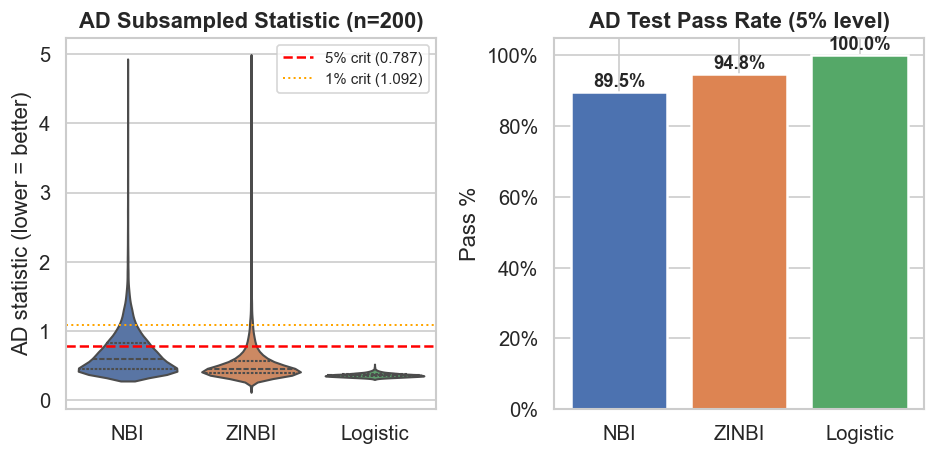

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
palette   = {'NBI': '#4C72B0', 'ZINBI': '#DD8452', 'Logistic': '#55A868'}
models_present = [m for m in ['NBI', 'ZINBI', 'Logistic']
                  if m in all_df['model'].unique()]

# ── Violin: AD sub distribution ──────────────────────────────────
ax = axes[0]
plot_df = all_df[all_df['ad_sub'].between(0, 5)]
sns.violinplot(data=plot_df, x='model', y='ad_sub', order=models_present,
               palette=palette, inner='quartile', cut=0, ax=ax)
ax.axhline(0.787, color='red', lw=1.5, ls='--', label='5% crit (0.787)')
ax.axhline(1.092, color='orange', lw=1.2, ls=':', label='1% crit (1.092)')
ax.set_title('AD Subsampled Statistic (n=200)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('AD statistic (lower = better)')
ax.legend(fontsize=9)

# ── Bar: AD pass rate ─────────────────────────────────────────────
ax = axes[1]
pass_rates = all_df.groupby('model')['ad_pass'].mean().reindex(models_present) * 100
bars = ax.bar(pass_rates.index, pass_rates.values,
              color=[palette[m] for m in pass_rates.index], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, pass_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('AD Test Pass Rate (5% level)', fontweight='bold')
ax.set_ylabel('Pass %'); ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_ad_comparison.png', bbox_inches='tight')
plt.show()

## 3. Z-score 보정 품질 (mean, std)

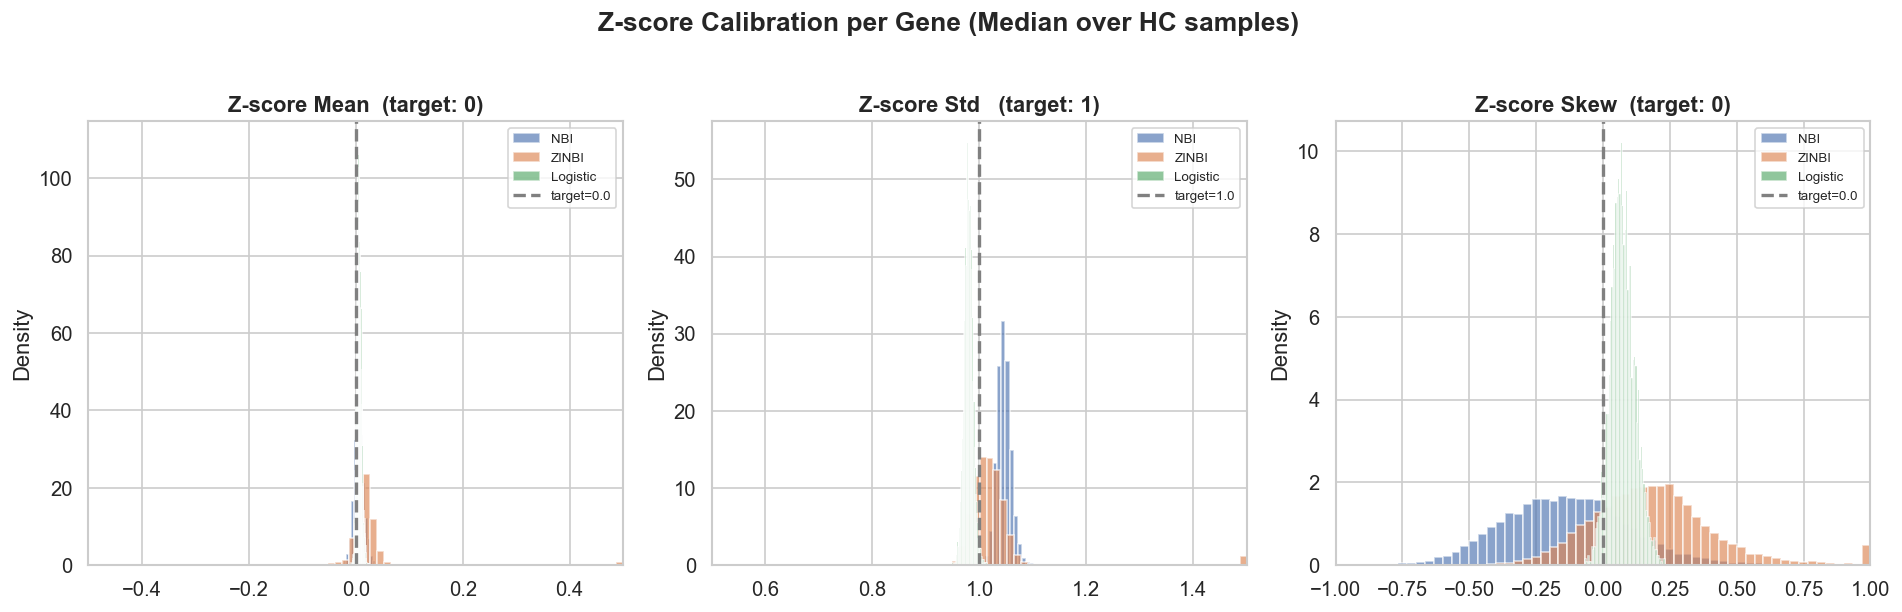

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('mean_z',  'Z-score Mean  (target: 0)',  (-0.5, 0.5),    0.0,  'grey'),
    ('std_z',   'Z-score Std   (target: 1)',  (0.5, 1.5), 1.0,  'grey'),
    ('skew_z',  'Z-score Skew  (target: 0)',  (-1, 1),    0.0,  'grey'),
]

for ax, (col, title, xlim, target, tcolor) in zip(axes, metrics):
    for model in models_present:
        vals = all_df.loc[all_df['model'] == model, col].dropna()
        vals_clipped = vals.clip(*xlim)
        ax.hist(vals_clipped, bins=60, alpha=0.65, label=model,
                color=palette[model], density=True)
    ax.axvline(target, color=tcolor, lw=2, ls='--', label=f'target={target}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(*xlim)
    ax.legend(fontsize=8)
    ax.set_xlabel(''); ax.set_ylabel('Density')

plt.suptitle('Z-score Calibration per Gene (Median over HC samples)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_zscore_calibration.png', bbox_inches='tight')
plt.show()

## 4. Detection rate별 AD 성능 (모델별 커버리지)

In [5]:
models_present

['NBI', 'ZINBI', 'Logistic']

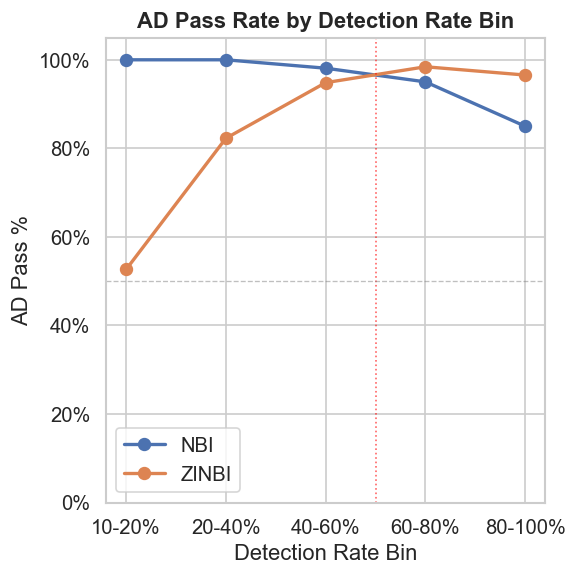

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

# Bin by detection rate
bins = np.array([0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.01])
labels = ['0-1%','1-5%','5-10%','10-20%','20-40%','40-60%','60-80%','80-100%']

for model in ['NBI', 'ZINBI']:
    sub = all_df[all_df['model'] == model].copy()
    sub['det_bin'] = pd.cut(sub['det_rate'], bins=bins, labels=labels, right=False)
    pass_by_bin = sub.groupby('det_bin', observed=True)['ad_pass'].mean() * 100
    ax.plot(pass_by_bin.index, pass_by_bin.values, 'o-',
            label=model, color=palette[model], lw=2, ms=7)

ax.axvline(2.5, color='red', lw=1, ls=':', alpha=0.6)  # det_rate=10% boundary (between bin 2 and 3)
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_title('AD Pass Rate by Detection Rate Bin', fontweight='bold')
ax.set_ylabel('AD Pass %')
ax.set_xlabel('Detection Rate Bin')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_ad_by_detrate.png', bbox_inches='tight')
plt.show()

## 5. Fold 성공률 & Outlier 제거

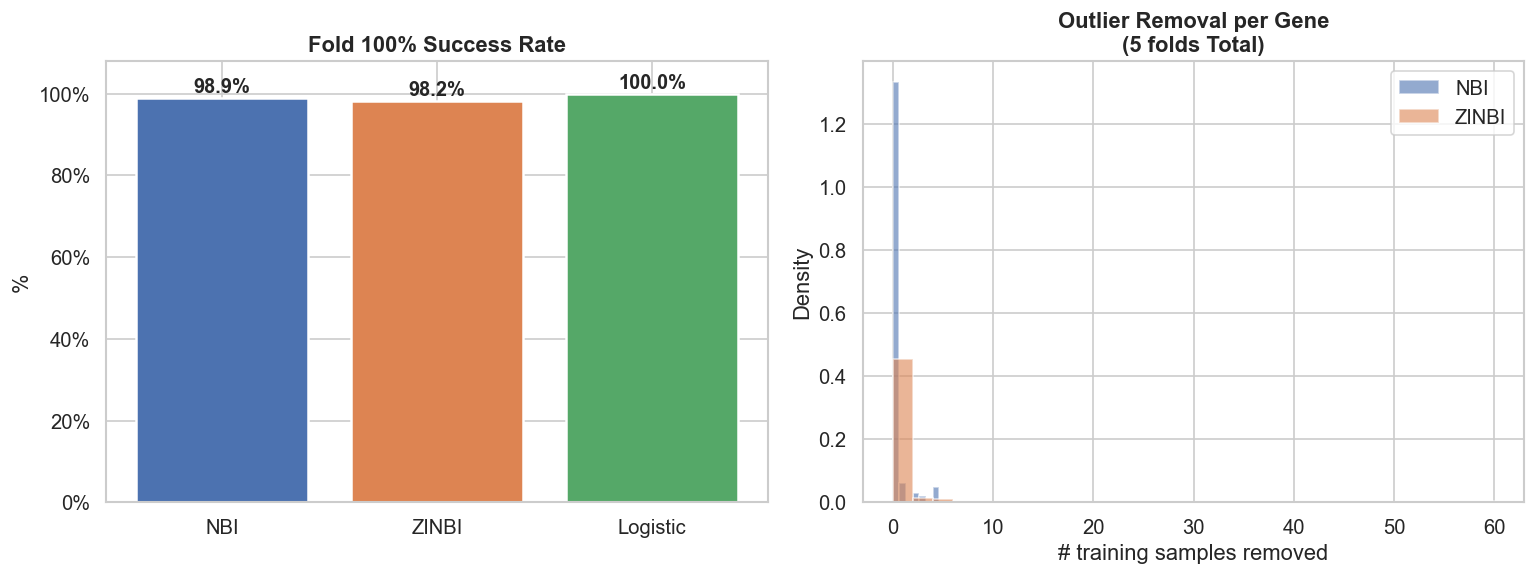

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Fold 100% success rate per model ────────────────────────
ax = axes[0]
fold_ok_full = (all_df.groupby('model')['fold_ok']
                .apply(lambda x: (x == 1.0).mean() * 100)
                .reindex(models_present))
bars = ax.bar(fold_ok_full.index, fold_ok_full.values,
              color=[palette[m] for m in fold_ok_full.index], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, fold_ok_full.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Fold 100% Success Rate', fontweight='bold')
ax.set_ylabel('%')

# ── Right: Outlier removed per gene ──────────────────────────────
ax = axes[1]
for model in [m for m in models_present if m != 'Logistic']:
    vals = all_df[all_df['model'] == model]['n_removed'].clip(0, 60)
    ax.hist(vals, bins=30, alpha=0.6, label=model, color=palette[model], density=True)
ax.set_title('Outlier Removal per Gene\n(5 folds Total)', fontweight='bold')
ax.set_xlabel('# training samples removed')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_fold_outlier.png', bbox_inches='tight')
plt.show()

## 6. ZINBI 전용: Binary vs Count_cond vs Full z-score 비교

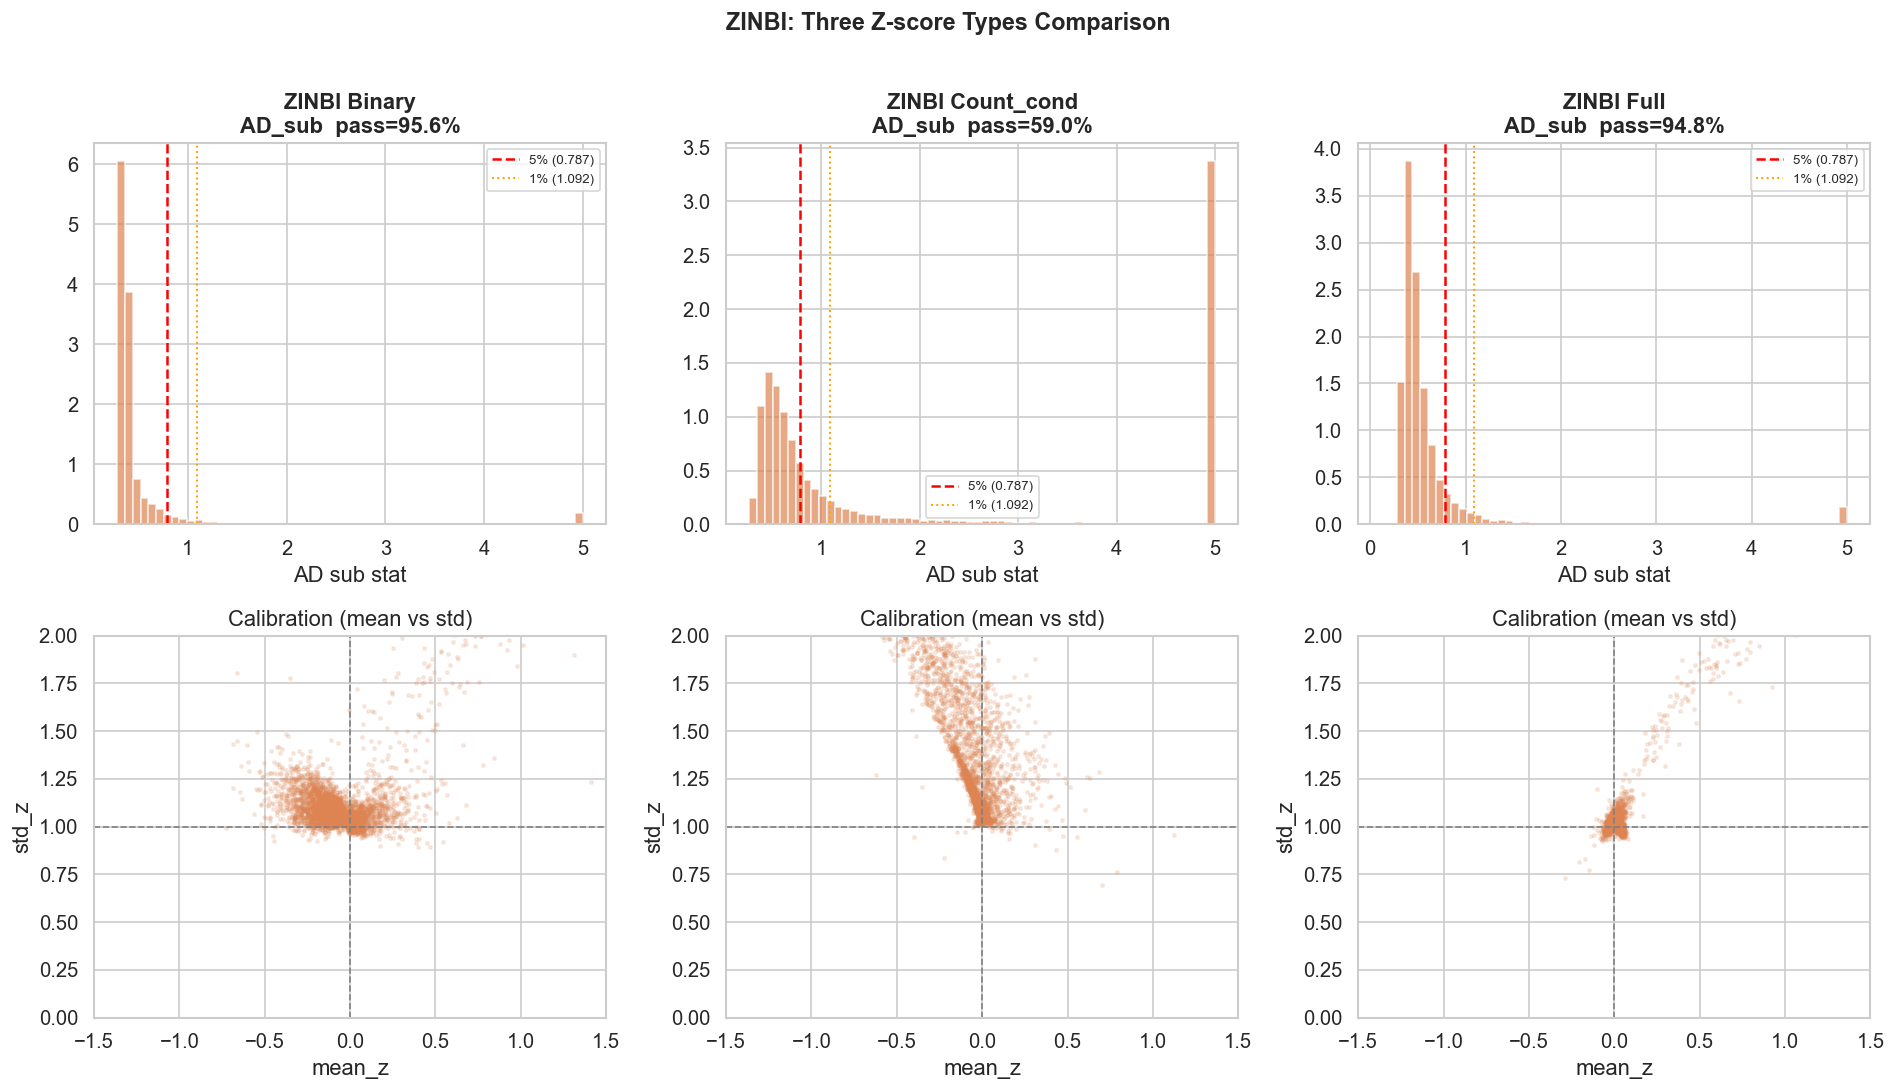

In [11]:
if zinb is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    zscore_types = [
        ('Binary',    'ads_binary',    'ads_binary_pass',    'mean_binary_z',    'std_binary_z'),
        ('Count_cond','ads_count_cond','ads_count_cond_pass','mean_count_cond_z','std_count_cond_z'),
        ('Full',      'ads_full',      'ads_full_pass',      'mean_full_z',      'std_full_z'),
    ]

    for col_idx, (ztype, ad_col, pass_col, mz_col, sz_col) in enumerate(zscore_types):
        ax_ad = axes[0, col_idx]
        ax_cal = axes[1, col_idx]

        # AD distribution
        vals = zinb[ad_col].dropna().clip(0, 5)
        ax_ad.hist(vals, bins=60, color='#DD8452', alpha=0.7, density=True)
        ax_ad.axvline(0.787, color='red',   lw=1.5, ls='--', label='5% (0.787)')
        ax_ad.axvline(1.092, color='orange',lw=1.2, ls=':',  label='1% (1.092)')
        pass_rate = zinb[pass_col].mean() * 100
        ax_ad.set_title(f'ZINBI {ztype}\nAD_sub  pass={pass_rate:.1f}%', fontweight='bold')
        ax_ad.set_xlabel('AD sub stat'); ax_ad.legend(fontsize=8)

        # Mean/Std scatter
        mz = zinb[mz_col].dropna()
        sz = zinb[sz_col].dropna()
        idx = mz.index.intersection(sz.index)
        ax_cal.scatter(mz[idx], sz[idx], alpha=0.15, s=4, color='#DD8452')
        ax_cal.axvline(0, color='grey', lw=1, ls='--')
        ax_cal.axhline(1, color='grey', lw=1, ls='--')
        ax_cal.set_xlim(-1.5, 1.5); ax_cal.set_ylim(0, 2)
        ax_cal.set_xlabel('mean_z'); ax_cal.set_ylabel('std_z')
        ax_cal.set_title(f'Calibration (mean vs std)')

    plt.suptitle('ZINBI: Three Z-score Types Comparison', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_zinbi_zscore_types.png', bbox_inches='tight')
    plt.show()
else:
    print('ZINBI results not yet available.')

## 7. Failure Flag 분석

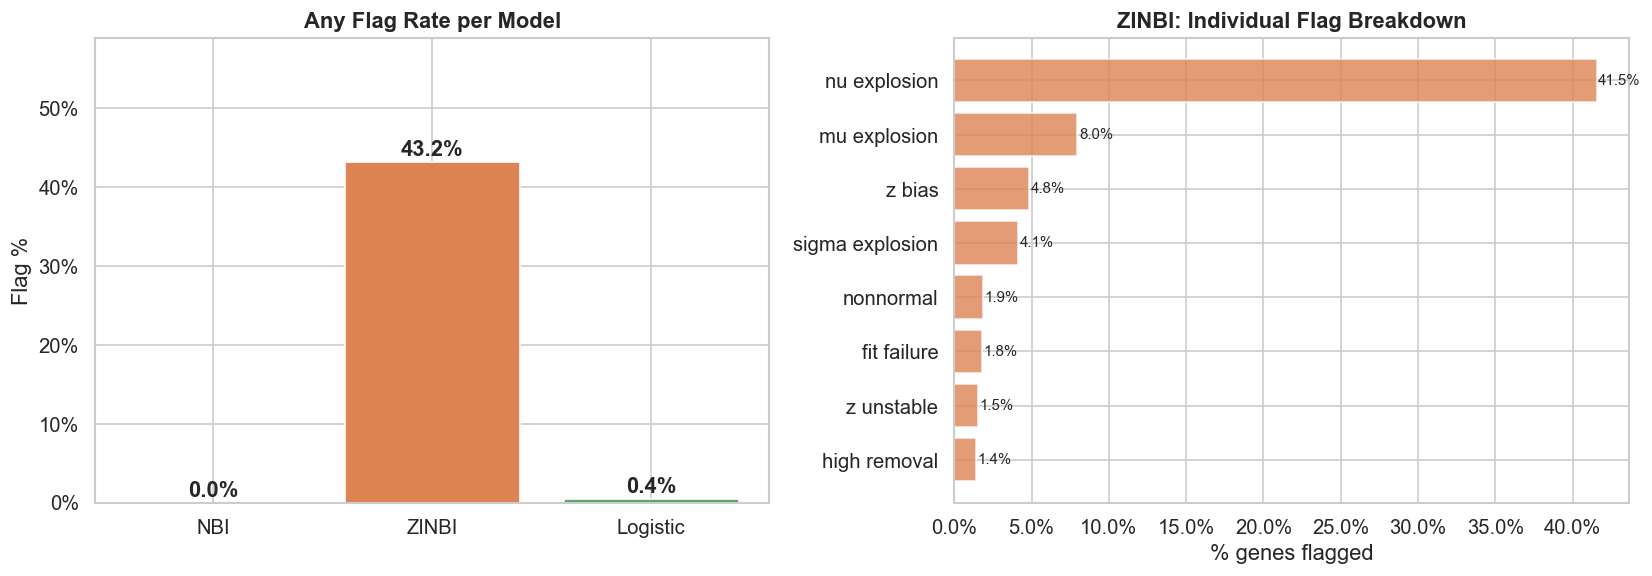

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Flag rate per model ───────────────────────────────────────────
ax = axes[0]
flag_rates = (all_df.groupby('model')['any_flag'].mean() * 100).reindex(models_present)
bars = ax.bar(flag_rates.index, flag_rates.values,
              color=[palette[m] for m in flag_rates.index], edgecolor='white')
for bar, v in zip(bars, flag_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Any Flag Rate per Model', fontweight='bold')
ax.set_ylabel('Flag %'); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(flag_rates.values) * 1.25 + 5)

# ── ZINBI flag breakdown ──────────────────────────────────────────
ax = axes[1]
if zinb is not None:
    flag_cols = [c for c in zinb.columns if c.startswith('flag_') and c != 'any_flag']
    flag_pcts = (zinb[flag_cols].mean() * 100).sort_values(ascending=True)
    flag_labels = [c.replace('flag_', '').replace('_', ' ') for c in flag_pcts.index]
    ax.barh(flag_labels, flag_pcts.values, color='#DD8452', alpha=0.8)
    ax.set_title('ZINBI: Individual Flag Breakdown', fontweight='bold')
    ax.set_xlabel('% genes flagged')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    for i, v in enumerate(flag_pcts.values):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
elif logr is not None:
    flag_cols = [c for c in logr.columns if c.startswith('flag_') and c != 'any_flag']
    flag_pcts = (logr[flag_cols].mean() * 100).sort_values(ascending=True)
    flag_labels = [c.replace('flag_', '').replace('_', ' ') for c in flag_pcts.index]
    ax.barh(flag_labels, flag_pcts.values, color='#55A868', alpha=0.8)
    ax.set_title('Logistic: Individual Flag Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_flags.png', bbox_inches='tight')
plt.show()

## 8. NBI vs ZINBI 유전자별 직접 비교 (공통 유전자)

NBI ∩ ZINBI 공통 유전자: 10,663개


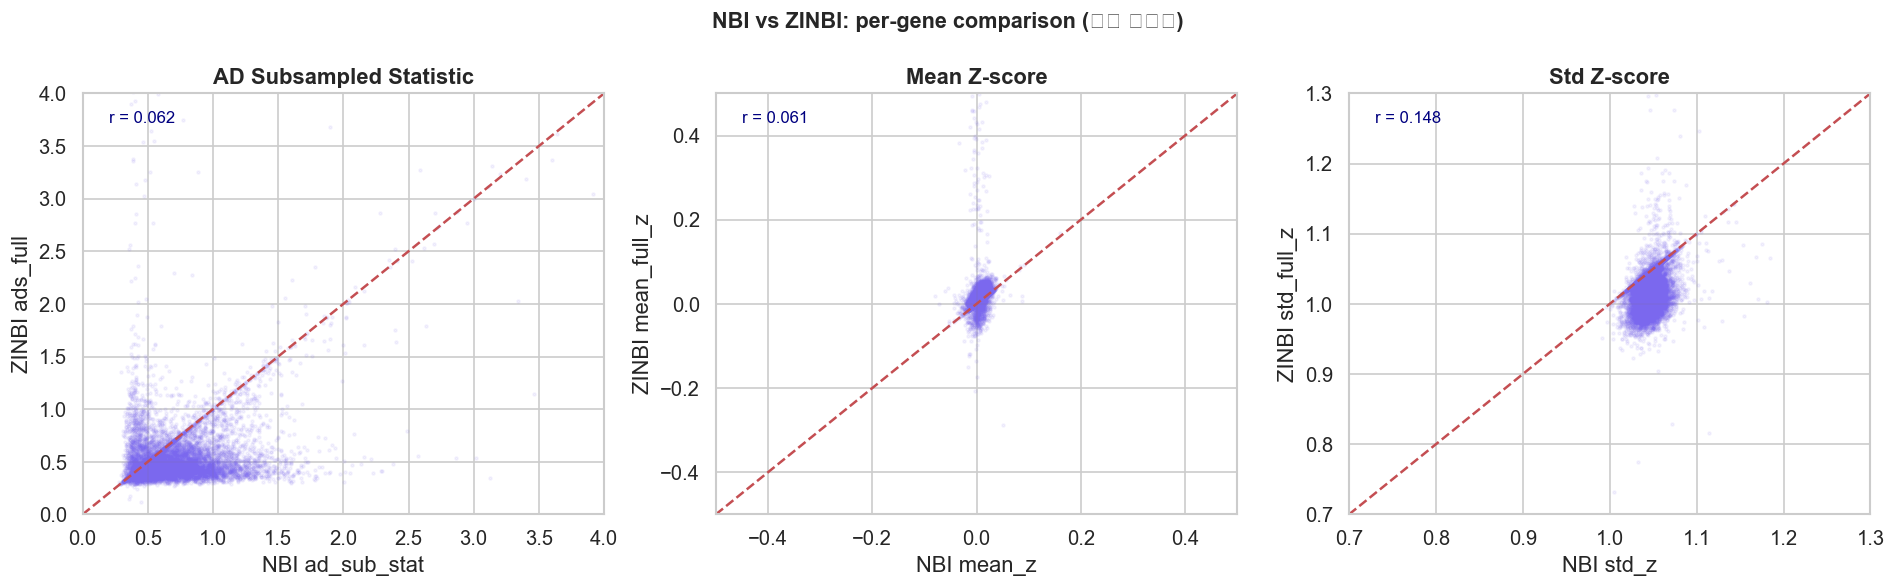

In [13]:
if nb is not None and zinb is not None:
    common = set(nb['gene']) & set(zinb['gene'])
    print(f'NBI ∩ ZINBI 공통 유전자: {len(common):,}개')

    nb_c   = nb[nb['gene'].isin(common)].set_index('gene')
    zinb_c = zinb[zinb['gene'].isin(common)].set_index('gene')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    comparisons = [
        ('ad_sub_stat', 'ads_full',       'AD Subsampled Statistic', (0, 4)),
        ('mean_z',      'mean_full_z',    'Mean Z-score',            (-0.5, 0.5)),
        ('std_z',       'std_full_z',     'Std Z-score',             (0.7, 1.3)),
    ]

    for ax, (nb_col, zinb_col, title, lim) in zip(axes, comparisons):
        x = nb_c[nb_col].reindex(list(common))
        y = zinb_c[zinb_col].reindex(list(common))
        valid = x.notna() & y.notna()
        ax.scatter(x[valid], y[valid], alpha=0.08, s=3, color='#7B68EE')
        mn, mx = lim
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='diagonal')
        ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
        ax.set_xlabel(f'NBI {nb_col}')
        ax.set_ylabel(f'ZINBI {zinb_col}')
        ax.set_title(title, fontweight='bold')

        # Correlation
        corr = x[valid].corr(y[valid])
        ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=10, color='navy')

    plt.suptitle('NBI vs ZINBI: per-gene comparison (공통 유전자)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_nbi_vs_zinbi.png', bbox_inches='tight')
    plt.show()
else:
    print('NBI 또는 ZINBI 결과 미완료. 추후 재실행 필요.')

## 9. 최종 권고 요약

In [14]:
print('=' * 65)
print('  Model Performance Summary')
print('=' * 65)

for model in models_present:
    sub = all_df[all_df['model'] == model]
    n   = len(sub)
    ad_pass   = sub['ad_pass'].mean() * 100
    fold_ok   = (sub['fold_ok'] == 1.0).mean() * 100
    med_ad    = sub['ad_sub'].median()
    med_mean  = sub['mean_z'].median()
    med_std   = sub['std_z'].median()
    flag_rate = sub['any_flag'].mean() * 100

    print(f"\n[{model}]  {n:,} genes")
    print(f"  AD pass rate  : {ad_pass:.1f}%   (higher = better)")
    print(f"  Fold ok rate  : {fold_ok:.1f}%   (target: 100%)")
    print(f"  Median AD_sub : {med_ad:.3f}    (lower = closer to N(0,1))")
    print(f"  Median mean_z : {med_mean:+.4f}  (target: 0.0)")
    print(f"  Median std_z  : {med_std:.4f}   (target: 1.0)")
    print(f"  Flag rate     : {flag_rate:.1f}%   (lower = better)")

print('\n' + '=' * 65)
print('Generated figures → CV_Results/fig_*.png')
print('=' * 65)

  Model Performance Summary

[NBI]  15,185 genes
  AD pass rate  : 89.5%   (higher = better)
  Fold ok rate  : 98.9%   (target: 100%)
  Median AD_sub : 0.604    (lower = closer to N(0,1))
  Median mean_z : +0.0055  (target: 0.0)
  Median std_z  : 1.0456   (target: 1.0)
  Flag rate     : 0.0%   (lower = better)

[ZINBI]  10,663 genes
  AD pass rate  : 94.8%   (higher = better)
  Fold ok rate  : 98.2%   (target: 100%)
  Median AD_sub : 0.461    (lower = closer to N(0,1))
  Median mean_z : +0.0152  (target: 0.0)
  Median std_z  : 1.0167   (target: 1.0)
  Flag rate     : 43.2%   (lower = better)

[Logistic]  2,762 genes
  AD pass rate  : 100.0%   (higher = better)
  Fold ok rate  : 100.0%   (target: 100%)
  Median AD_sub : 0.362    (lower = closer to N(0,1))
  Median mean_z : +0.0065  (target: 0.0)
  Median std_z  : 0.9797   (target: 1.0)
  Flag rate     : 0.4%   (lower = better)

Generated figures → CV_Results/fig_*.png
